Image loaded successfully.


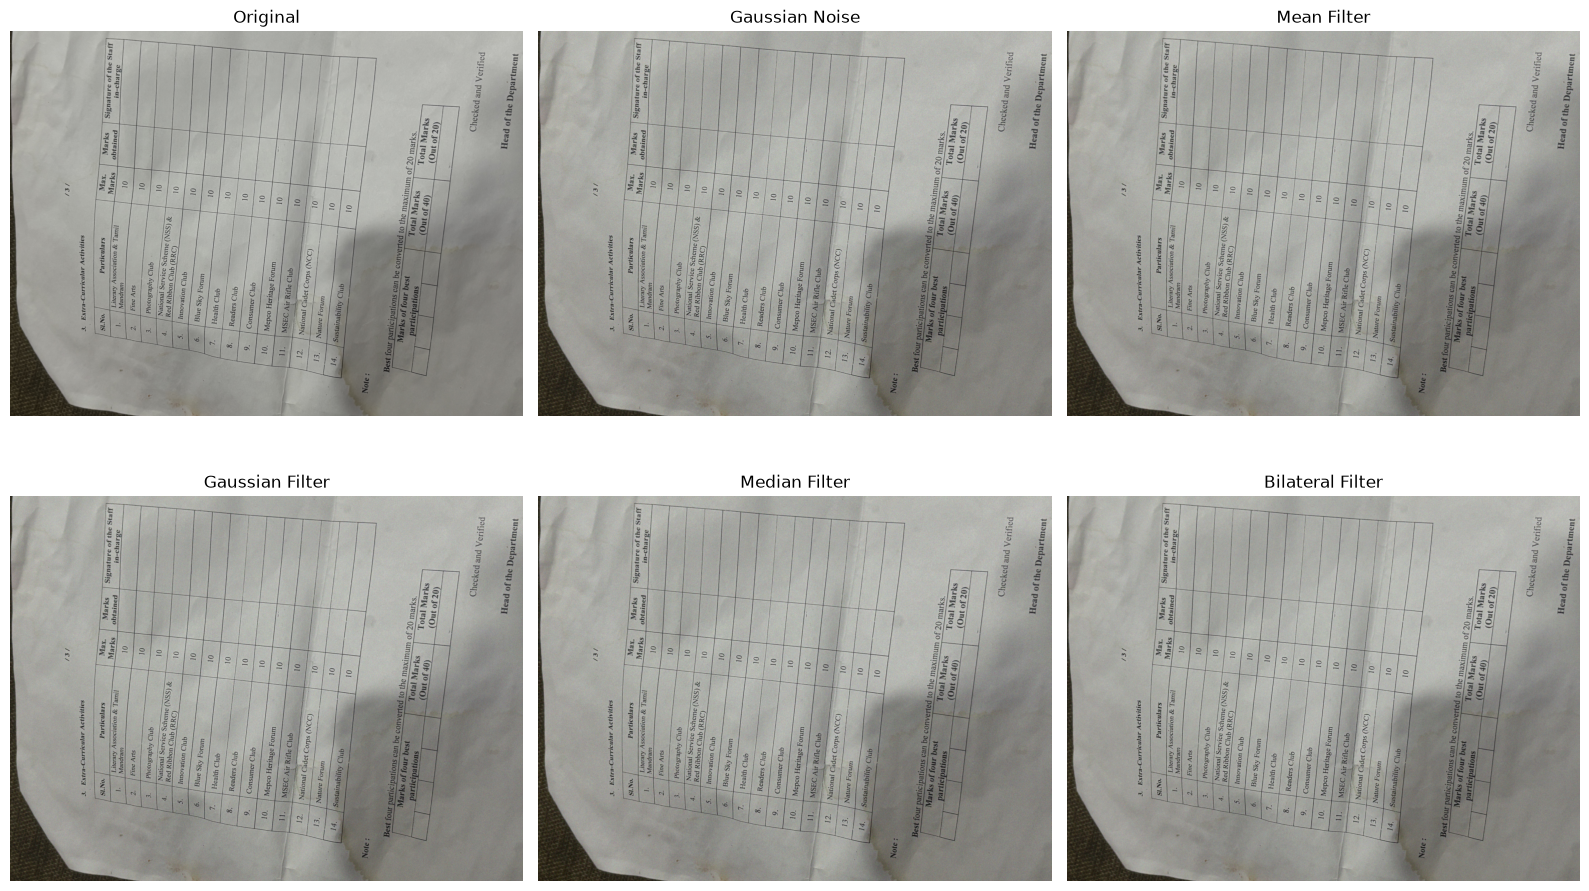

In [1]:
# Task 4: Noise and Filtering

## Aim

#To study the effect of different filtering techniques on a noisy image by adding Gaussian noise to a document image and comparing the output of Mean, Gaussian, Median, and Bilateral filters.

## Theory

#Noise is unwanted variation in image intensity that can reduce image quality. Different filters are used to remove noise while preserving image details.

#- Mean Filter smooths the image by averaging neighboring pixels.
#- Gaussian Filter applies weighted averaging and produces smoother results.
#- Median Filter replaces each pixel with the median value of its neighbors, making it effective for impulse noise.
#- Bilateral Filter smooths the image while preserving edges.

## Prediction

#Before applying the filters, I expect the **Bilateral Filter** to preserve the text edges the best because it smooths the image while maintaining sharp edges. The Mean and Gaussian filters may blur the text slightly, while the Median filter is generally better for salt-and-pepper noise than Gaussian noise.

import cv2
import numpy as np
import matplotlib.pyplot as plt
img = cv2.imread("/Users/suriya/Documents/opencv/SuriyaKumar/raw_captures/document.jpg")

if img is None:
    print("Image not found.")
else:
    print("Image loaded successfully.")

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
mean = 0
sigma = 25

noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)

noisy = img.astype(np.float32) + noise

noisy = np.clip(noisy, 0, 255).astype(np.uint8)

mean_filter = cv2.blur(noisy, (5,5))
gaussian_filter = cv2.GaussianBlur(noisy, (5,5), 0)
median_filter = cv2.medianBlur(noisy, 5)
bilateral_filter = cv2.bilateralFilter(
    noisy,
    9,
    75,
    75
)
images = [
    rgb,
    cv2.cvtColor(noisy, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(mean_filter, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(gaussian_filter, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(median_filter, cv2.COLOR_BGR2RGB),
    cv2.cvtColor(bilateral_filter, cv2.COLOR_BGR2RGB)
]

titles = [
    "Original",
    "Gaussian Noise",
    "Mean Filter",
    "Gaussian Filter",
    "Median Filter",
    "Bilateral Filter"
]

plt.figure(figsize=(16,10))

for i in range(len(images)):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()
## Observation

#Gaussian noise was successfully added to the document image. The noisy image showed random intensity variations that reduced text clarity.

#The Mean and Gaussian filters removed a significant amount of noise but slightly blurred the text edges.

#The Median filter removed some noise while preserving the text better than the Mean filter.

#The Bilateral filter preserved the edges of the text most effectively while reducing noise, making the characters appear sharper than the other filtered images.

## Comparison

#| Filter | Observation |
#|---------|-------------|
#| Mean Filter | Reduced noise but blurred text edges. |
#| Gaussian Filter | Produced smoother output but slightly blurred characters. |
#| Median Filter | Preserved text better than Mean filter. |
#| Bilateral Filter | Best edge preservation while reducing noise. |

## Conclusion

#Different filtering techniques produce different results depending on the type of noise. In this experiment, the Bilateral filter preserved the text edges better while reducing Gaussian noise. This matched my initial prediction.